# Problem: Detecting fraudulent app usage data with STL and confidence intervals
You are given app usage data, tracking the daily active users. You want to determine anomlies that are indicative of any suspicious activity, such as bots.

We will use Seasonal Trend Decomposition (STL)  decomposition and combine it with statistical methods to detect anomalies in time-series data.  




This code imports essential Python libraries for data analysis, visualization, and time series decomposition:

STL from statsmodels.tsa.seasonal is used for for Seasonal-Trend decomposition of time series data.








In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from statsmodels.tsa.seasonal import STL

In the next cell, load the dataset from the file and display its contents to examine the data structure.


In [1]:
# Your code to read the data using pandas. Assign the data to a variable named 'df'
# Your code to Print few rows of the dataset to see how it looks.
import pandas as pd

# Read the dataset into a DataFrame
df = pd.read_csv('/content/product_usage_data.csv')  # Replace with your actual dataset path

# Print the first few rows of the dataset
print(df.head())  # By default, head() shows the first 5 rows


  timestamp  daily_active_users
0  1/1/2024                1107
1  1/2/2024                1113
2  1/3/2024                1143
3  1/4/2024                1140
4  1/5/2024                1136


Following code converts the 'timestamp' column in the DataFrame df to a datetime format using pandas.to_datetime(), ensuring that the values are recognized as datetime objects for easier time-based operations and analysis


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])


Use the following code to display the first few rows of the updated DataFrame and verify the modifications:


In [4]:
# Your code to  see the updated data. Print first few rows.
# Print the first few rows of the updated dataset
print(df.head())  # This will display the first 5 rows of the updated DataFrame


   timestamp  daily_active_users
0 2024-01-01                1107
1 2024-01-02                1113
2 2024-01-03                1143
3 2024-01-04                1140
4 2024-01-05                1136


Following  code creates a pandas Series named dau using the values from the 'daily_active_users' column of the DataFrame df, setting the 'timestamp' column as the index to enable time series operations.


In [6]:
dau = pd.Series(data=df['daily_active_users'].values, index=df['timestamp'])


In the next cell, plot the dau data using the Matplotlib library. Ensure that the plot includes appropriate labels for the x-axis and y-axis, as well as a suitable title.



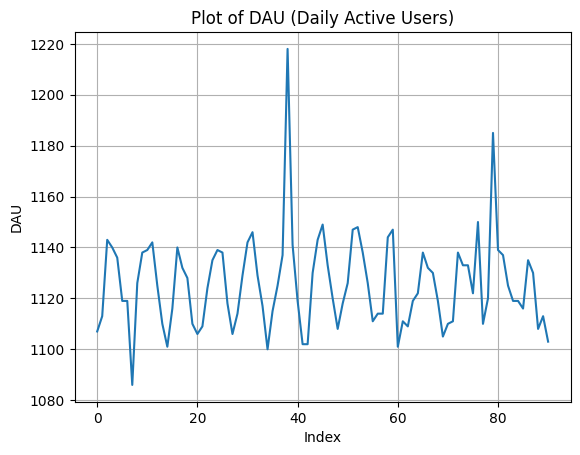

In [9]:
#
#
#
# Your code to Plot the data 'dau' using matplot library. Give suitable names to the x label, y label and title
#
#
import matplotlib.pyplot as plt

# Access the 'daily_active_users' column instead of the non-existent 'dau' column
plt.plot(df['daily_active_users'])

# Adding labels and title
plt.xlabel('Index')  # x-axis label (typically index or time if the data is time-series)
plt.ylabel('DAU')  # y-axis label (Data column)
plt.title('Plot of DAU (Daily Active Users)')  # Title of the plot

# Display the plot
plt.grid(True)
plt.show()

The code dau.describe() is calling the .describe() method on a DataFrame named dau.



In [10]:
dau.describe()


,0
count,91.000000
mean,1125.703297
std,18.362700
min,1086.000000
25%,1113.000000
50%,1125.000000
75%,1138.000000
max,1218.000000


Folloiwng code decomposes the time series data dau into trend, seasonal, and residual components using the STL method, specifying weekly seasonality (period=7), and stores the results in res.


In [11]:
stl = STL(dau, period=7)  # weekly seasonality
res = stl.fit()



In the following cell, print the different time series components.

In [12]:
print(res.seasonal)
print(res.seasonal)
# Your code to print trend component
print(res.trend) # Print the trend component
# Your code to print residual component. res.resid is the residual component
print (res.resid) # Print the residual component
print (res.resid)

timestamp
2024-01-01   -29.112699
2024-01-02    -9.007788
2024-01-03    16.681902
2024-01-04    10.810216
2024-01-05    13.981569
                ...    
2024-03-27    26.987993
2024-03-28     6.704833
2024-03-29    -0.830159
2024-03-30    -1.994414
2024-03-31    -2.578938
Name: season, Length: 91, dtype: float64
timestamp
2024-01-01   -29.112699
2024-01-02    -9.007788
2024-01-03    16.681902
2024-01-04    10.810216
2024-01-05    13.981569
                ...    
2024-03-27    26.987993
2024-03-28     6.704833
2024-03-29    -0.830159
2024-03-30    -1.994414
2024-03-31    -2.578938
Name: season, Length: 91, dtype: float64
timestamp
2024-01-01    1128.320578
2024-01-02    1127.468131
2024-01-03    1126.682798
2024-01-04    1125.964042
2024-01-05    1125.315609
                 ...     
2024-03-27    1119.600989
2024-03-28    1116.557829
2024-03-29    1113.511075
2024-03-30    1110.462253
2024-03-31    1107.416218
Name: trend, Length: 91, dtype: float64
timestamp
2024-01-01     7.792122


Following code, creates the plot of various time series components like, trend, seasonality, and residual.

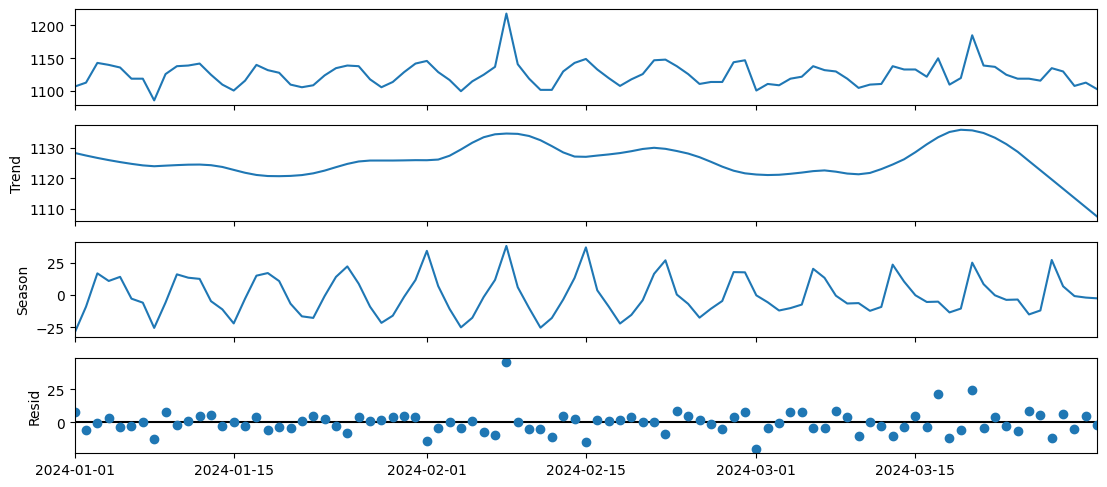

In [13]:
#plot 4 components, original, residual, trend, and noise using matplotlib

fig = res.plot()
fig.set_size_inches(12, 5)
plt.show()

Following code is used for minor anomaly detection by defining an upper and lower threshold around the trend component of the time series. These thresholds, trend_iv_l_minor and trend_iv_u_minor, are set by adjusting the trend with the mean and standard deviation of the residuals. Values outside this range can be considered anomalies, as they deviate significantly from the expected trend behavior.

In [14]:
trend_iv_l_minor = pd.Series(data=res.trend.values-np.mean(res.trend)-np.std(res.resid), index=res.trend.index)
trend_iv_u_minor = pd.Series(data=res.trend.values-np.mean(res.trend)+np.std(res.resid), index=res.trend.index)\

minor_anom = np.where((res.resid < trend_iv_l_minor) | (res.resid > trend_iv_u_minor), res.resid, np.nan)


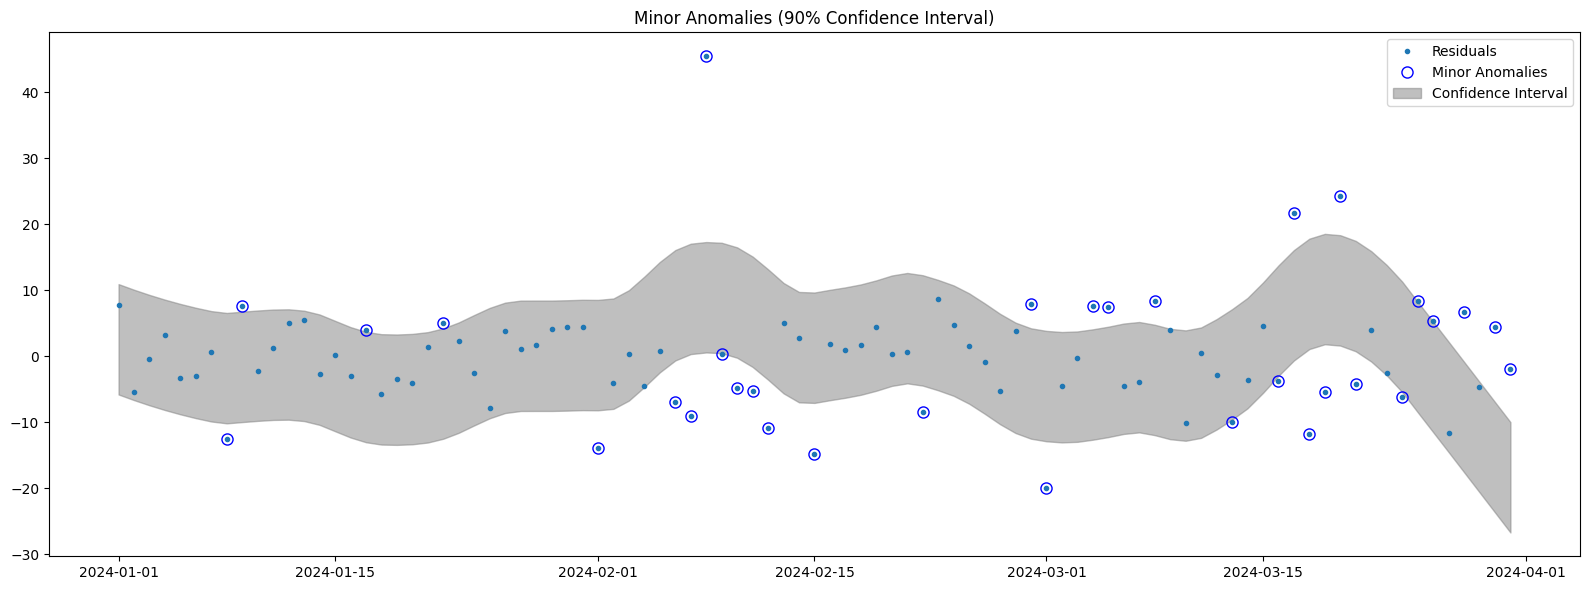

In [15]:
import matplotlib.pyplot as plt
import pandas as pd


# Create a single figure with one axis (ax)
fig, ax = plt.subplots(figsize=(16, 6))
# Plot the residuals
ax.plot(res.resid, marker='.', linestyle='none', label='Residuals')
# Plot the minor anomalies (blue circles)
ax.plot(pd.Series(minor_anom, res.resid.index), marker='o', linestyle='none', label='Minor Anomalies', color='blue', fillstyle='none', markersize=8)
# Fill the confidence interval (grey shaded area)
ax.fill_between(res.resid.index, trend_iv_l_minor, trend_iv_u_minor, color='grey', alpha=0.5, label='Confidence Interval')
# Set the title and labels
ax.set_title('Minor Anomalies (90% Confidence Interval)')
# Add a legend
ax.legend()
# Display the plot
plt.tight_layout()
plt.show()



Bsed on the above code, write Python code to find anomalies that are 2 times and 3 times away from standard deviation. Use trend component for detecting anomalies.

In [16]:
#
#
# Your code to find the anomalies that are 2 standard deviations away from the residuals
#
#
#
# Your code to find the anomalies that are 2 standard deviations away from the residuals
#
#
trend_iv_l_major = pd.Series(data=res.trend.values-np.mean(res.trend)-2*np.std(res.resid), index=res.trend.index)
trend_iv_u_major = pd.Series(data=res.trend.values-np.mean(res.trend)+2*np.std(res.resid), index=res.trend.index)

major_anom = np.where((res.resid < trend_iv_l_major) | (res.resid > trend_iv_u_major), res.resid, np.nan)

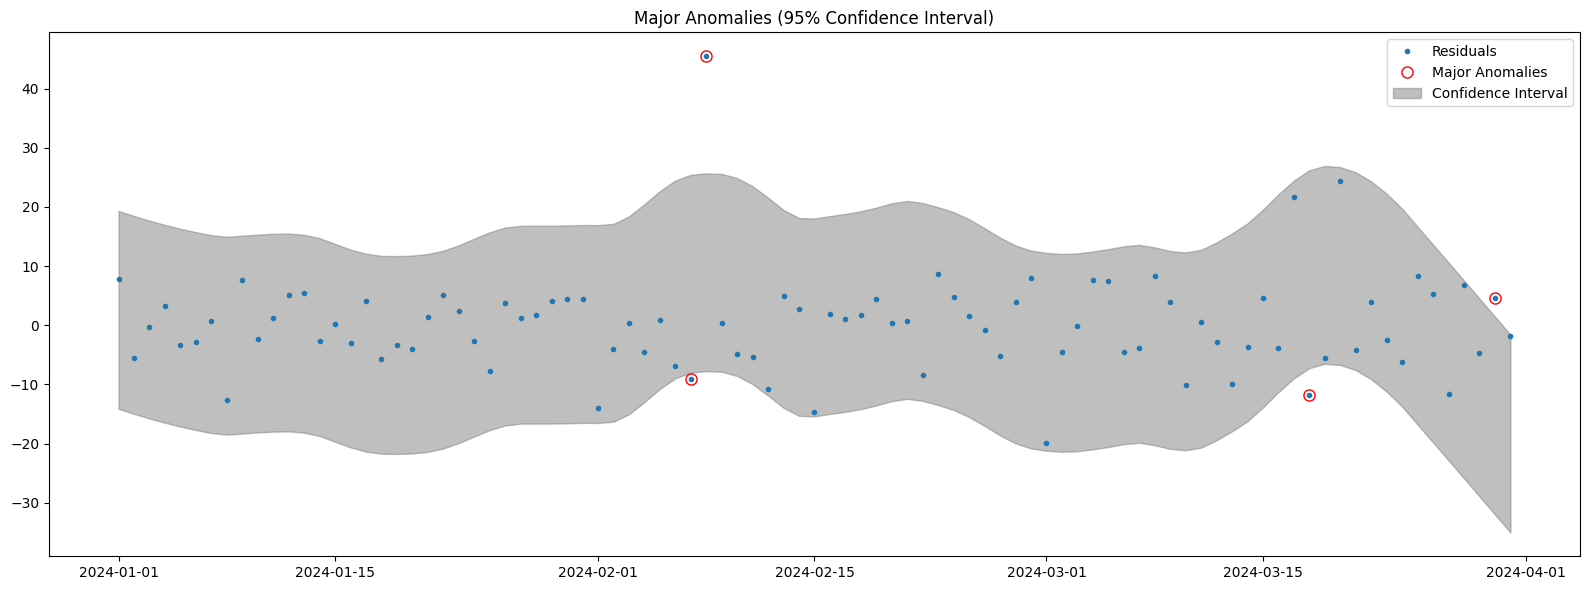

In [17]:
#
#
# Your code to plot the anomalies and the residuals.
#
#
# Your code to plot the anomalies and the residuals.
import matplotlib.pyplot as plt
import pandas as pd


# Create a single figure with one axis (ax)
fig, ax = plt.subplots(figsize=(16, 6))
# Plot the residuals
ax.plot(res.resid, marker='.', linestyle='none', label='Residuals')
# Plot the major anomalies (red circles)
ax.plot(pd.Series(major_anom, res.resid.index), marker='o', linestyle='none', label='Major Anomalies', color='red', fillstyle='none', markersize=8)
# Fill the confidence interval (grey shaded area)
ax.fill_between(res.resid.index, trend_iv_l_major, trend_iv_u_major, color='grey', alpha=0.5, label='Confidence Interval')
# Set the title and labels
ax.set_title('Major Anomalies (95% Confidence Interval)')
# Add a legend
ax.legend()
# Display the plot
plt.tight_layout()
plt.show()

In [18]:
#
#
# Your code to find the anomalies that are 3 standard deviations away from the residuals
#
#
#
#
# Your code to find the anomalies that are 3 standard deviations away from the residuals
#
#
trend_iv_l_critical = pd.Series(data=res.trend.values-np.mean(res.trend)-3*np.std(res.resid), index=res.trend.index)
trend_iv_u_critical = pd.Series(data=res.trend.values-np.mean(res.trend)+3*np.std(res.resid), index=res.trend.index)

critical_anom = np.where((res.resid < trend_iv_l_critical) | (res.resid > trend_iv_u_critical), res.resid, np.nan)

In [20]:
#
#
# Your code to plot the anomalies and the residuals.
#
#
#
#
# Your code to find the anomalies that are 3 standard deviations away from the residuals
#
#
trend_iv_l_critical = pd.Series(data=res.trend.values-np.mean(res.trend)-3*np.std(res.resid), index=res.trend.index)
trend_iv_u_critical = pd.Series(data=res.trend.values-np.mean(res.trend)+3*np.std(res.resid), index=res.trend.index)

critical_anom = np.where((res.resid < trend_iv_l_critical) | (res.resid > trend_iv_u_critical), res.resid, np.nan)

Using a similar approach, write Python code to detect anomalies using the Z-score method. Apply 2-3 threshold values to detect anomalies, using the residual component for detection. Note that the formula for the Z-score is:
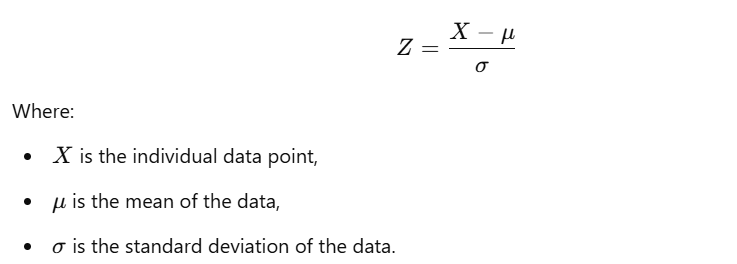

A point x is anomaly if Z-score for that point is greater than threshold.


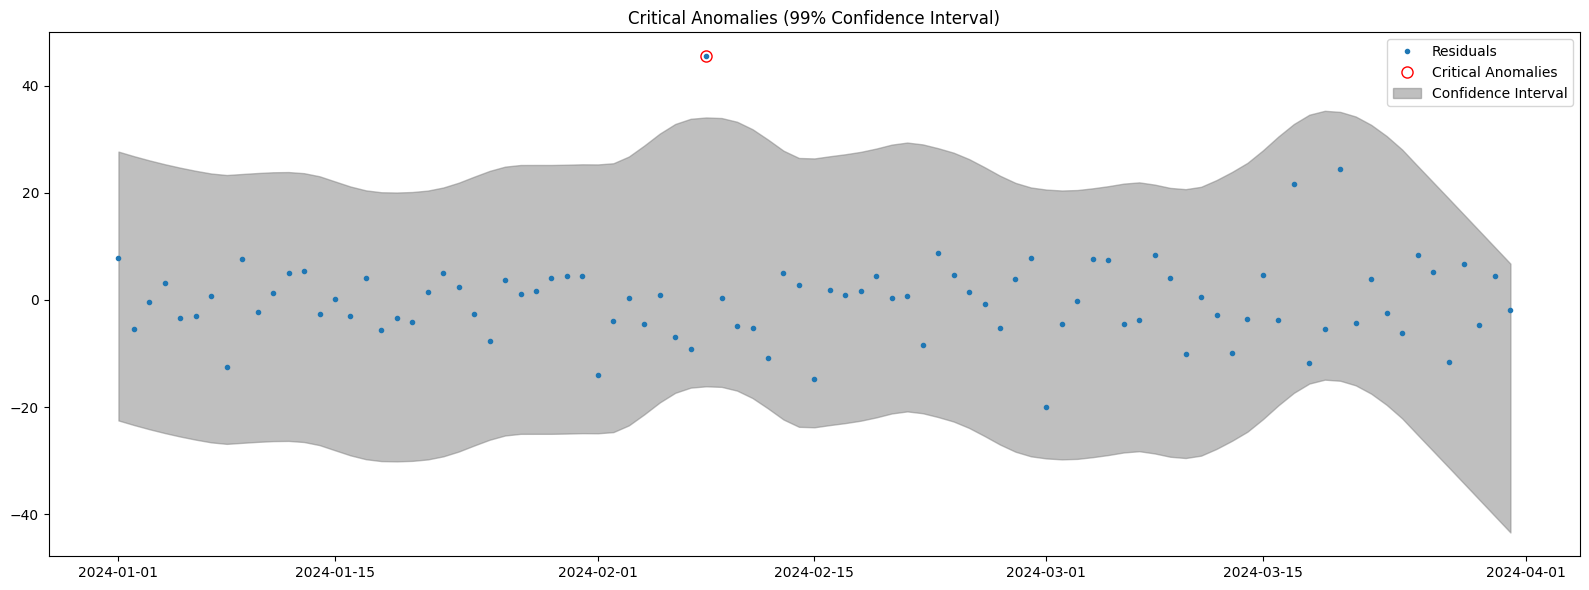

In [21]:

#
# Your code to detect the anomalies using Z-score method. Use 2-3 different threshold.
#

#
#
#
#
# Your code to plot the anomalies and the residuals.
#
#

import matplotlib.pyplot as plt
import pandas as pd


# Create a single figure with one axis (ax)
fig, ax = plt.subplots(figsize=(16, 6))
# Plot the residuals
ax.plot(res.resid, marker='.', linestyle='none', label='Residuals')
# Plot the critical anomalies (red circles)
ax.plot(pd.Series(critical_anom, res.resid.index), marker='o', linestyle='none', label='Critical Anomalies', color='red', fillstyle='none', markersize=8)
# Fill the confidence interval (grey shaded area)
ax.fill_between(res.resid.index, trend_iv_l_critical, trend_iv_u_critical, color='grey', alpha=0.5, label='Confidence Interval')
# Set the title and labels
ax.set_title('Critical Anomalies (99% Confidence Interval)')
# Add a legend
ax.legend()
# Display the plot
plt.tight_layout()
plt.show()

#Important: Lab Logbook Requirement:
#Plot the anomalies in next cell and include this graph in your lab logbook."

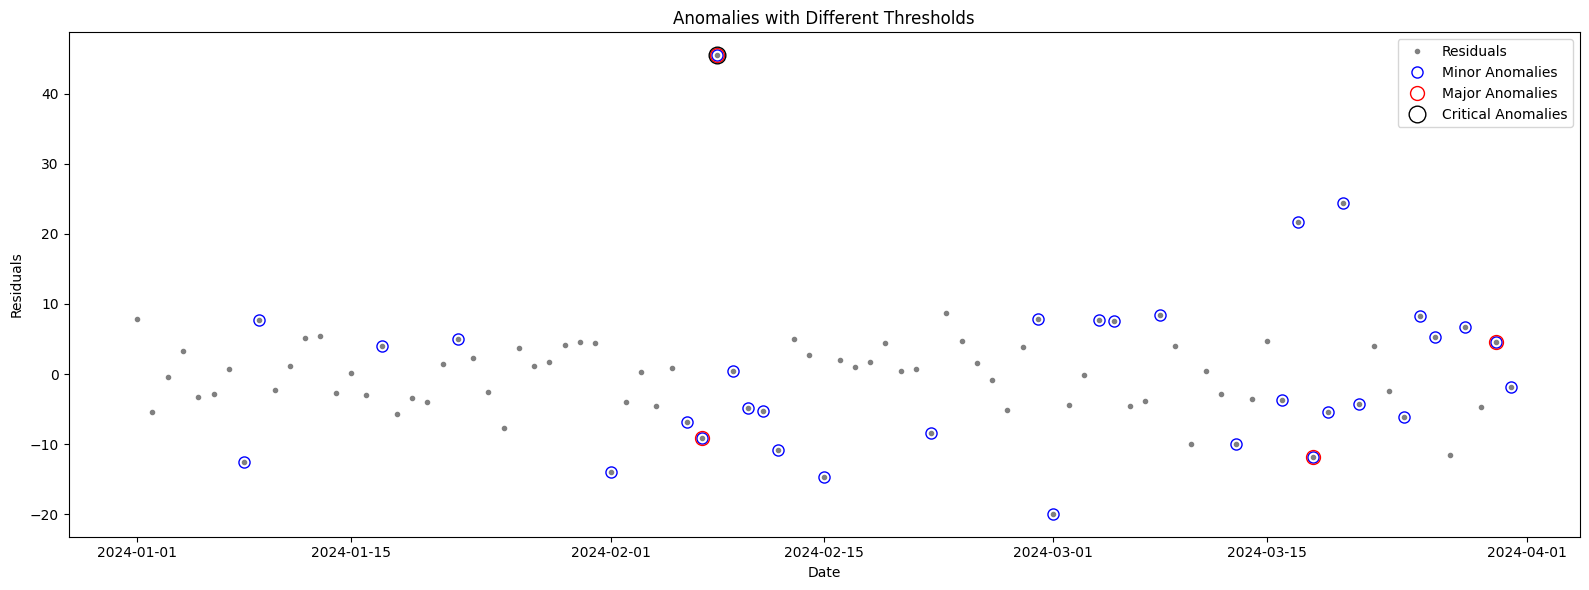

In [22]:
#
# Your code to plot the anomalies for three different types of threshold.
#
# Your code to plot the anomalies for three different types of threshold.
import matplotlib.pyplot as plt
import pandas as pd

# Create a single figure with one axis (ax)
fig, ax = plt.subplots(figsize=(16, 6))

# Plot the residuals
ax.plot(res.resid, marker='.', linestyle='none', label='Residuals', color='gray')  # Changed color to gray for better contrast

# Plot the minor anomalies (blue circles)
ax.plot(pd.Series(minor_anom, res.resid.index), marker='o', linestyle='none', label='Minor Anomalies', color='blue', fillstyle='none', markersize=8)

# Plot the major anomalies (red circles)
ax.plot(pd.Series(major_anom, res.resid.index), marker='o', linestyle='none', label='Major Anomalies', color='red', fillstyle='none', markersize=10)  # Increased size

# Plot the critical anomalies (black circles)
ax.plot(pd.Series(critical_anom, res.resid.index), marker='o', linestyle='none', label='Critical Anomalies', color='black', fillstyle='none', markersize=12)  # Increased size further

# Set the title and labels
ax.set_title('Anomalies with Different Thresholds')
ax.set_xlabel('Date')
ax.set_ylabel('Residuals')

# Add a legend
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()

Using a similar approach, write Python code to detect anomalies using the IQR method. Apply 2-3 threshold values to detect anomalies, using the residual component for detection. Note that the formula for the IQR is:

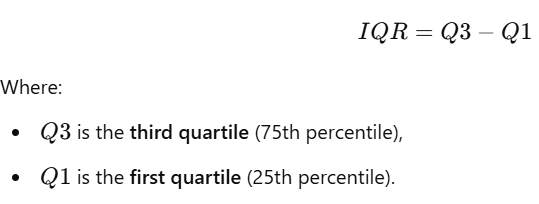

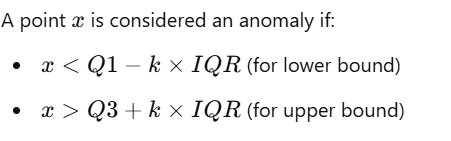

In [23]:
#
#
# Your code to detect the anomalies using IQR method. Use 2-3 different threshold.
#
#
# Your code to detect the anomalies using IQR method. Use 2-3 different threshold.

# Calculate the IQR
Q1 = res.resid.quantile(0.25)
Q3 = res.resid.quantile(0.75)
IQR = Q3 - Q1

# Define thresholds
threshold1 = 1.5  # For moderate anomalies
threshold2 = 3.0  # For extreme anomalies

# Identify anomalies
lower_bound1 = Q1 - threshold1 * IQR
upper_bound1 = Q3 + threshold1 * IQR
moderate_anomalies = res.resid[(res.resid < lower_bound1) | (res.resid > upper_bound1)]

lower_bound2 = Q1 - threshold2 * IQR
upper_bound2 = Q3 + threshold2 * IQR
extreme_anomalies = res.resid[(res.resid < lower_bound2) | (res.resid > upper_bound2)]

#Important: Lab Logbook Requirement:
#Plot the anomalies in next cell and include this graph in your lab logbook."

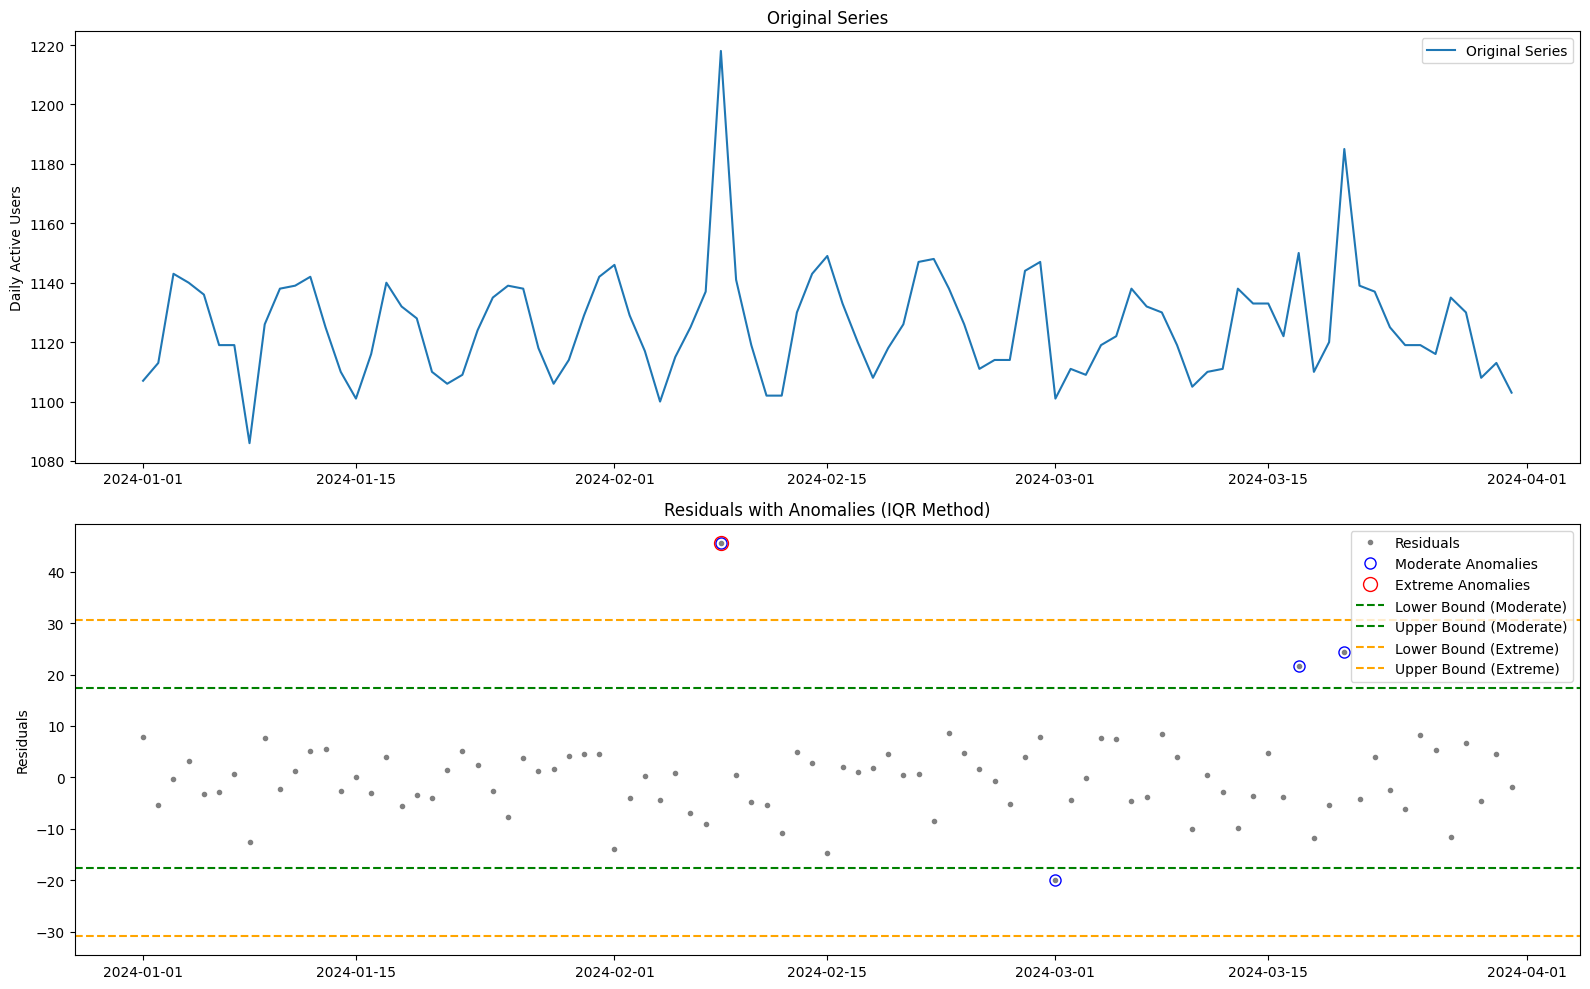

In [24]:
#
#
# Your code to plot the anomalies for three different k values.
# Plot original series as well as residuals.
#
#
# Your code to plot the anomalies for three different k values.
# Plot original series as well as residuals.
import matplotlib.pyplot as plt
import pandas as pd

# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot original series
ax1.plot(dau, label='Original Series')
ax1.set_title('Original Series')
ax1.set_ylabel('Daily Active Users')
ax1.legend()

# Plot residuals and anomalies
ax2.plot(res.resid, marker='.', linestyle='none', label='Residuals', color='gray')

# Highlight moderate anomalies
ax2.plot(moderate_anomalies.index, moderate_anomalies.values, marker='o', linestyle='none', label='Moderate Anomalies', color='blue', fillstyle='none', markersize=8)

# Highlight extreme anomalies
ax2.plot(extreme_anomalies.index, extreme_anomalies.values, marker='o', linestyle='none', label='Extreme Anomalies', color='red', fillstyle='none', markersize=10)

# Add confidence interval lines
ax2.axhline(lower_bound1, color='green', linestyle='--', label='Lower Bound (Moderate)')
ax2.axhline(upper_bound1, color='green', linestyle='--', label='Upper Bound (Moderate)')
ax2.axhline(lower_bound2, color='orange', linestyle='--', label='Lower Bound (Extreme)')
ax2.axhline(upper_bound2, color='orange', linestyle='--', label='Upper Bound (Extreme)')

ax2.set_title('Residuals with Anomalies (IQR Method)')
ax2.set_ylabel('Residuals')
ax2.legend()

plt.tight_layout()
plt.show()

## Folooing section is optional for this lab.

The code below uses Linear Regression. Based on the following code write your own code to detect anomalies in using ARIMA which is also one of the regression algorithm.

ARIMA is a model used to predict future value in a time series.
It looks at past data to find patterns and trends.

AR (AutoRegressive): Uses past values to predict future ones.
I (Integrated): Makes the data more stable by removing trends.
MA (Moving Average): Uses past errors (differences between actual and predicted values) to improve predictions.

You can use the Python library statsmodels.tsa.arima.model to implement ARIMA.
https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html

You need to compare the ARIMA prediction and actual values and if they are significantly different then the points can be considered as anomolous.







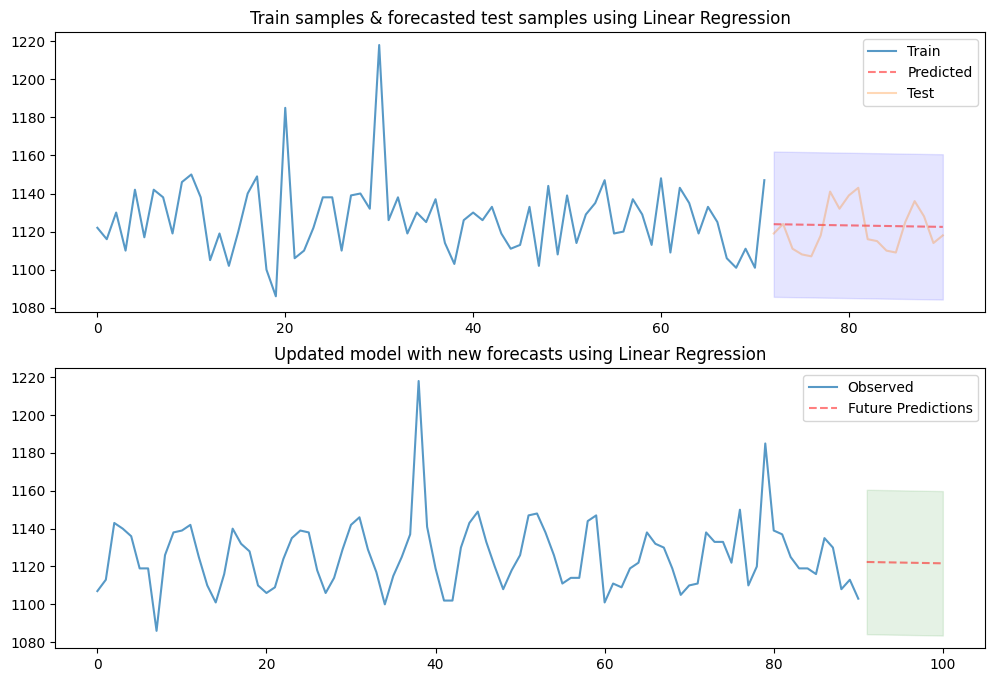

MSE for Linear Regression Forecast: 133.6046


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Splitting data into train and test
train, test = train_test_split(dau.values, train_size=0.8, random_state=42)

# Creating time indices as features for regression
train_indices = np.arange(len(train)).reshape(-1, 1)
test_indices = np.arange(len(train), len(train) + len(test)).reshape(-1, 1)

# Training linear regression model
model = LinearRegression()
model.fit(train_indices, train)

# Making predictions
preds = model.predict(test_indices)

# Calculating confidence intervals (assuming normal distribution of residuals)
residuals = train - model.predict(train_indices)
std_dev = np.std(residuals)
conf_int = np.column_stack((preds - 1.96 * std_dev, preds + 1.96 * std_dev))

# Plotting results
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
x_axis = np.arange(len(train) + len(test))
axes[0].plot(x_axis[:len(train)], train, alpha=0.75, label="Train")
axes[0].plot(x_axis[len(train):], preds, alpha=0.5, linestyle='--', color='r', label="Predicted")
axes[0].plot(x_axis[len(train):], test, alpha=0.3, label="Test")
axes[0].fill_between(x_axis[len(train):], conf_int[:, 0], conf_int[:, 1], alpha=0.1, color='b')
axes[0].set_title("Train samples & forecasted test samples using Linear Regression")
axes[0].legend()

# Detecting anomalies
anomalies = (test < conf_int[:, 0]) | (test > conf_int[:, 1])
axes[0].scatter(x_axis[len(train):][anomalies], test[anomalies], color='red', label="Anomalies")

# Updating model with test data and predicting future values
new_indices = np.arange(len(dau.values), len(dau.values) + 10).reshape(-1, 1)
new_preds = model.predict(new_indices)
new_conf_int = np.column_stack((new_preds - 1.96 * std_dev, new_preds + 1.96 * std_dev))

axes[1].plot(np.arange(len(dau.values)), dau, alpha=0.75, label="Observed")
axes[1].plot(new_indices, new_preds, alpha=0.5, linestyle='--', color='r', label="Future Predictions")
axes[1].fill_between(new_indices.flatten(), new_conf_int[:, 0], new_conf_int[:, 1], alpha=0.1, color='g')
axes[1].set_title("Updated model with new forecasts using Linear Regression")
axes[1].legend()
plt.show()

# Compute MSE
mse_linear = mean_squared_error(test, preds)
print(f"MSE for Linear Regression Forecast: {mse_linear:.4f}")